### 1.Business Understanding

### Dubai Apartment Price Prediction

### Problem Statement

The objective of this project is to analyze Dubai apartment listings and identify the factors influencing property prices.

The project aims to:

- Understand Dubai apartment market trends
- Identify key drivers of property prices
- Perform exploratory data analysis (EDA)
- Engineer meaningful features
- Prepare the dataset for machine learning models

Target Variable:
- price

Potential Predictors:
- area
- beds
- baths
- district
- furnishing status
- amenities

### 2.Imports & Configuration

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

plt.style.use("ggplot")

### 3.Data Loading

In [2]:
df = pd.read_csv("data/ready_cleaned.csv")

print(df.shape)

df.head()

(16777, 88)


,sub_district,district,city,location,price,beds,baths,area,description,property_type,furnished,double_glazed_windows,electricity_backup,lobby_in_building,central_heating,view,freehold,parking_spaces,maintenance_staff,maintenance_staff.1,storage_areas,parking_spaces.1,nearby_shopping_malls,electricity_backup.1,day_care_center,view.1,facilities_for_disabled,intercom,atm_facility,shared_kitchen,shared_kitchen.1,first_aid_medical_center,lobby_in_building.1,balcony_or_terrace,prayer_room,barbeque_area,conference_room,gym_or_health_club,satellite/cable_tv,business_center,barbeque_area.1,waste_disposal,waste_disposal.1,storage_areas.1,prayer_room.1,double_glazed_windows.1,service_elevators,furnished.1,flooring,day_care_center.1,study_room,business_center.1,cleaning_services,maids_room,centrally_air_conditioned,conference_room.1,lawn_or_garden,freehold.1,sauna,broadband_internet,steam_room,service_elevators.1,sauna.1,laundry_room,security_staff,laundry_facility,centrally_air_conditioned.1,gym_or_health_club.1,balcony_or_terrace.1,kids_play_area,first_aid_medical_center.1,cafeteria_or_canteen,maids_room.1,satellite/cable_tv.1,jacuzzi,jacuzzi.1,study_room.1,nearby_shopping_malls.1,furnished.2,lawn_or_garden.1,cctv_security,swimming_pool,swimming_pool.1,reception/waiting_room,security_staff.1,kids_play_area.1,flooring.1,steam_room.1
0,JVC District 13,Jumeirah Village Circle (JVC),Dubai,"Pantheon Boulevard, JVC District 13, Jumeirah ...",1000000.0,1,2.0,999.0,Azco Real Estate is pleased to offer this amaz...,Apartment,Unfurnished,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0
1,JVC District 10,Jumeirah Village Circle (JVC),Dubai,"Binghatti Corner, JVC District 10, Jumeirah Vi...",880000.0,1,2.0,686.0,Al Arfeen Real Estate is pleased to offer an E...,Apartment,Unfurnished,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,JVC District 13,Jumeirah Village Circle (JVC),Dubai,"Pantheon Elysee I, JVC District 13, Jumeirah V...",1030000.0,1,2.0,893.0,"Luxury UPGRADED 1bhk | 10,59,000 | Mighty Size...",Apartment,Furnished,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0
3,Golfville,Dubai Hills Estate,Dubai,"Golfville, Dubai Hills Estate, Dubai",1850000.0,2,1.0,765.0,Vacant | Brand New | Payment Plan | 2 Beds- 2 ...,Apartment,Furnished,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,JVC District 12,Jumeirah Village Circle (JVC),Dubai,"Binghatti Luna, JVC District 12, Jumeirah Vill...",900000.0,1,2.0,647.0,Azco Real Estate is delighted to offer this st...,Apartment,Furnished,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0


### 4. Dataset Overview

In [3]:
df.info()
df.describe()
df.columns.tolist()

<class 'pandas.DataFrame'>
RangeIndex: 16777 entries, 0 to 16776
Data columns (total 88 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   sub_district                 16752 non-null  str    
 1   district                     16752 non-null  str    
 2   city                         16694 non-null  str    
 3   location                     16752 non-null  str    
 4   price                        16752 non-null  float64
 5   beds                         16752 non-null  str    
 6   baths                        16752 non-null  float64
 7   area                         16752 non-null  float64
 8   description                  16751 non-null  str    
 9   property_type                16746 non-null  str    
 10  furnished                    15151 non-null  str    
 11  double_glazed_windows        16752 non-null  float64
 12  electricity_backup           16752 non-null  float64
 13  lobby_in_building          

['sub_district',
 'district',
 'city',
 'location',
 'price',
 'beds',
 'baths',
 'area',
 'description',
 'property_type',
 'furnished',
 'double_glazed_windows',
 'electricity_backup',
 'lobby_in_building',
 'central_heating',
 'view',
 'freehold',
 'parking_spaces',
 'maintenance_staff',
 'maintenance_staff.1',
 'storage_areas',
 'parking_spaces.1',
 'nearby_shopping_malls',
 'electricity_backup.1',
 'day_care_center',
 'view.1',
 'facilities_for_disabled',
 'intercom',
 'atm_facility',
 'shared_kitchen',
 'shared_kitchen.1',
 'first_aid_medical_center',
 'lobby_in_building.1',
 'balcony_or_terrace',
 'prayer_room',
 'barbeque_area',
 'conference_room',
 'gym_or_health_club',
 'satellite/cable_tv',
 'business_center',
 'barbeque_area.1',
 'waste_disposal',
 'waste_disposal.1',
 'storage_areas.1',
 'prayer_room.1',
 'double_glazed_windows.1',
 'service_elevators',
 'furnished.1',
 'flooring',
 'day_care_center.1',
 'study_room',
 'business_center.1',
 'cleaning_services',
 'maids_roo

### 5. Data Cleaning

#### 5.1 Missing Values

In [4]:
missing_values = (
    df.isnull()
      .sum()
      .sort_values(ascending=False)
)

missing_values.head(20)

furnished                1626
city                       83
property_type              31
description                26
price                      25
sub_district               25
district                   25
location                   25
area                       25
baths                      25
beds                       25
double_glazed_windows      25
electricity_backup         25
lobby_in_building          25
central_heating            25
view                       25
freehold                   25
parking_spaces             25
maintenance_staff          25
maintenance_staff.1        25
dtype: int64

Main missing feature:
- furnished

Minor missing values:
- price
- city
- property_type

Most columns have only 25 missing records.

### 5.2 Handle Furnished

In [5]:
df["furnished"] = df["furnished"].fillna("Unknown")

### 5.3 Clean Beds Column

In [6]:
df["beds"] = df["beds"].replace("Studio", 0)

df["beds"] = pd.to_numeric(df["beds"])

df["beds"].value_counts()

beds
1.0     6482
2.0     5282
0.0     2887
3.0     1812
4.0      265
5.0       19
6.0        3
7.0        1
10.0       1
Name: count, dtype: int64

### 5.4 Duplicate Column Investigation

In [7]:
duplicate_columns = [
    col
    for col in df.columns
    if ".1" in col
]

duplicate_columns

['maintenance_staff.1',
 'parking_spaces.1',
 'electricity_backup.1',
 'view.1',
 'shared_kitchen.1',
 'lobby_in_building.1',
 'barbeque_area.1',
 'waste_disposal.1',
 'storage_areas.1',
 'prayer_room.1',
 'double_glazed_windows.1',
 'furnished.1',
 'day_care_center.1',
 'business_center.1',
 'conference_room.1',
 'freehold.1',
 'service_elevators.1',
 'sauna.1',
 'centrally_air_conditioned.1',
 'gym_or_health_club.1',
 'balcony_or_terrace.1',
 'first_aid_medical_center.1',
 'maids_room.1',
 'satellite/cable_tv.1',
 'jacuzzi.1',
 'study_room.1',
 'nearby_shopping_malls.1',
 'lawn_or_garden.1',
 'swimming_pool.1',
 'security_staff.1',
 'kids_play_area.1',
 'flooring.1',
 'steam_room.1']

In [8]:
duplicate_pairs = [
    ("swimming_pool", "swimming_pool.1"),
    ("sauna", "sauna.1"),
    ("steam_room", "steam_room.1"),
    ("security_staff", "security_staff.1"),
    ("maids_room", "maids_room.1")
]

for col1, col2 in duplicate_pairs:
    print(f"\n{col1}")
    print(df[col1].value_counts())

    print(f"\n{col2}")
    print(df[col2].value_counts())


swimming_pool
swimming_pool
0.0    15925
1.0      827
Name: count, dtype: int64

swimming_pool.1
swimming_pool.1
1.0    8595
0.0    8157
Name: count, dtype: int64

sauna
sauna
0.0    16730
1.0       22
Name: count, dtype: int64

sauna.1
sauna.1
0.0    13307
1.0     3445
Name: count, dtype: int64

steam_room
steam_room
0.0    16745
1.0        7
Name: count, dtype: int64

steam_room.1
steam_room.1
0.0    14010
1.0     2742
Name: count, dtype: int64

security_staff
security_staff
0.0    9296
1.0    7456
Name: count, dtype: int64

security_staff.1
security_staff.1
0.0    16747
1.0        5
Name: count, dtype: int64

maids_room
maids_room
0.0    15941
1.0      811
Name: count, dtype: int64

maids_room.1
maids_room.1
0.0    16726
1.0       26
Name: count, dtype: int64


### 5.5 Duplicate Amenity Investigation

Several columns appeared duplicated with `.1` suffixes. Frequency analysis showed that these columns represent different scopes of amenities rather than true duplicates.

The original listing platform separates:
- Private unit features
- Building/community amenities

These columns were retained and renamed to preserve their business meaning.


| Original        | New Name                | Reason                                |
| --------------- | ----------------------- | ------------------------------------- |
| swimming_pool   | private_swimming_pool   | Rare feature, likely private amenity  |
| swimming_pool.1 | community_swimming_pool | Common feature, likely shared amenity |
| sauna           | private_sauna           | Very rare, likely in-unit             |
| sauna.1         | community_sauna         | Common building amenity               |


In [9]:
paired_cols = []

for col in df.columns:
    if col.endswith(".1"):
        original = col.replace(".1", "")
        if original in df.columns:
            paired_cols.append((original, col))


paired_cols

[('maintenance_staff', 'maintenance_staff.1'),
 ('parking_spaces', 'parking_spaces.1'),
 ('electricity_backup', 'electricity_backup.1'),
 ('view', 'view.1'),
 ('shared_kitchen', 'shared_kitchen.1'),
 ('lobby_in_building', 'lobby_in_building.1'),
 ('barbeque_area', 'barbeque_area.1'),
 ('waste_disposal', 'waste_disposal.1'),
 ('storage_areas', 'storage_areas.1'),
 ('prayer_room', 'prayer_room.1'),
 ('double_glazed_windows', 'double_glazed_windows.1'),
 ('furnished', 'furnished.1'),
 ('day_care_center', 'day_care_center.1'),
 ('business_center', 'business_center.1'),
 ('conference_room', 'conference_room.1'),
 ('freehold', 'freehold.1'),
 ('service_elevators', 'service_elevators.1'),
 ('sauna', 'sauna.1'),
 ('centrally_air_conditioned', 'centrally_air_conditioned.1'),
 ('gym_or_health_club', 'gym_or_health_club.1'),
 ('balcony_or_terrace', 'balcony_or_terrace.1'),
 ('first_aid_medical_center', 'first_aid_medical_center.1'),
 ('maids_room', 'maids_room.1'),
 ('satellite/cable_tv', 'satell

In [10]:
for col1, col2 in paired_cols:

    print("=" * 60)

    print(f"{col1}")
    print(df[col1].value_counts())

    print()

    print(f"{col2}")
    print(df[col2].value_counts())

    print()

maintenance_staff
maintenance_staff
0.0    16751
1.0        1
Name: count, dtype: int64

maintenance_staff.1
maintenance_staff.1
0.0    12729
1.0     4023
Name: count, dtype: int64

parking_spaces
parking_spaces
0.0    16502
1.0      250
Name: count, dtype: int64

parking_spaces.1
parking_spaces.1
0.0    14403
1.0     2349
Name: count, dtype: int64

electricity_backup
electricity_backup
0.0    14856
1.0     1896
Name: count, dtype: int64

electricity_backup.1
electricity_backup.1
0.0    16745
1.0        7
Name: count, dtype: int64

view
view
0.0    16727
1.0       25
Name: count, dtype: int64

view.1
view.1
0.0    14928
1.0     1824
Name: count, dtype: int64

shared_kitchen
shared_kitchen
0.0    16702
1.0       50
Name: count, dtype: int64

shared_kitchen.1
shared_kitchen.1
0.0    16227
1.0      525
Name: count, dtype: int64

lobby_in_building
lobby_in_building
0.0    16668
1.0       84
Name: count, dtype: int64

lobby_in_building.1
lobby_in_building.1
0.0    10163
1.0     6589
Name: c

In [11]:
rename_map = {

    "swimming_pool": "private_swimming_pool",
    "swimming_pool.1": "community_swimming_pool",

    "sauna": "private_sauna",
    "sauna.1": "community_sauna",

    "steam_room": "private_steam_room",
    "steam_room.1": "community_steam_room",

    "maintenance_staff": "private_maintenance_staff",
    "maintenance_staff.1": "community_maintenance_staff",

    "security_staff": "community_security_staff",
    "security_staff.1": "private_security_staff",

    "parking_spaces": "private_parking",
    "parking_spaces.1": "community_parking",

    "maids_room": "maids_room_primary",
    "maids_room.1": "maids_room_secondary"
}

df.rename(columns=rename_map, inplace=True)

In [12]:
df.columns

Index(['sub_district', 'district', 'city', 'location', 'price', 'beds',
       'baths', 'area', 'description', 'property_type', 'furnished',
       'double_glazed_windows', 'electricity_backup', 'lobby_in_building',
       'central_heating', 'view', 'freehold', 'private_parking',
       'private_maintenance_staff', 'community_maintenance_staff',
       'storage_areas', 'community_parking', 'nearby_shopping_malls',
       'electricity_backup.1', 'day_care_center', 'view.1',
       'facilities_for_disabled', 'intercom', 'atm_facility', 'shared_kitchen',
       'shared_kitchen.1', 'first_aid_medical_center', 'lobby_in_building.1',
       'balcony_or_terrace', 'prayer_room', 'barbeque_area', 'conference_room',
       'gym_or_health_club', 'satellite/cable_tv', 'business_center',
       'barbeque_area.1', 'waste_disposal', 'waste_disposal.1',
       'storage_areas.1', 'prayer_room.1', 'double_glazed_windows.1',
       'service_elevators', 'furnished.1', 'flooring', 'day_care_center.1',
    

### 6. Exploratory Data Analysis

#### 6.1 Target Variable Analysis

In [13]:
df['price'].describe()



#Distribution values
print("Mean:", df["price"].mean())
print("Median:", df["price"].median())
print("Min:", df["price"].min())
print("Max:", df["price"].max())

Mean: 2595936.465616046
Median: 1600000.0
Min: 270000.0
Max: 125000000.0


#### 6.2 Price Distribution

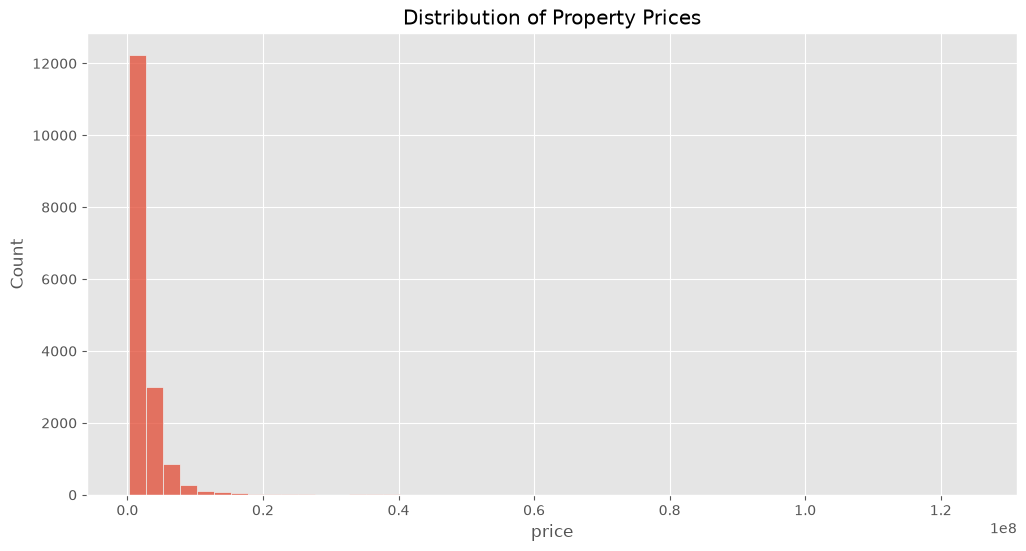

In [14]:
plt.figure(figsize = (12, 6))

sns.histplot(df["price"], bins=50)

plt.title("Distribution of Property Prices")

plt.show()

Observation:

Property prices are heavily right-skewed.

A small number of ultra-luxury properties significantly increase the mean property price.

#### 6.3 Area vs Price

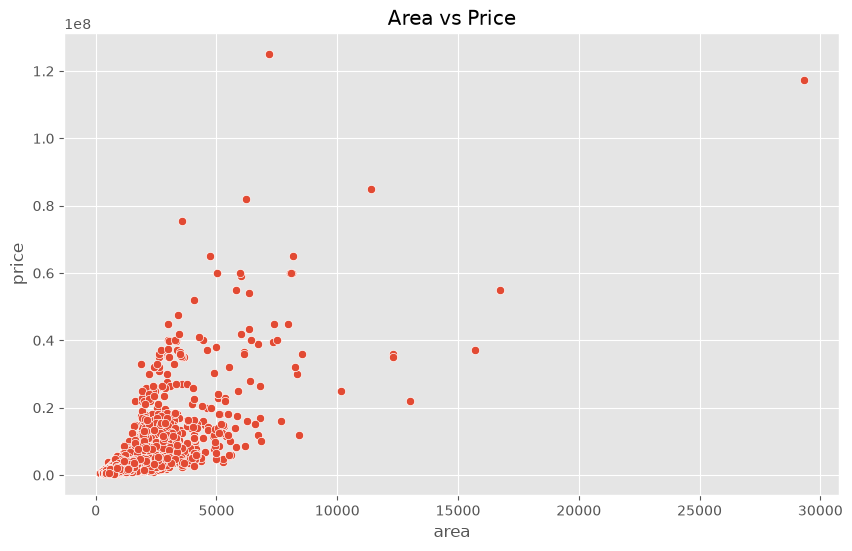

In [15]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x=df["area"],
    y=df["price"]
)

plt.title("Area vs Price")

plt.show()

Area shows a strong positive relationship with property prices.

Correlation:
0.71

#### 6.4 Bedrooms Analysis

In [16]:
df.groupby("beds")["price"] \
  .median() \
  .sort_index()

beds
0.0        650000.0
1.0       1300000.0
2.0       2500000.0
3.0       4500000.0
4.0       8999997.0
5.0      35000000.0
6.0      25000000.0
7.0     117302398.0
10.0     29997999.0
Name: price, dtype: float64

Observation:

Median property prices increase consistently with bedroom count.

#### 6.5 Bathrooms Analysis

In [17]:
df.groupby("baths")["price"] \
  .median() \
  .sort_index()

baths
1.0       900000.0
2.0      1500000.0
3.0      2750000.0
4.0      4500000.0
5.0      7599999.5
6.0     14700000.0
7.0     16120000.0
8.0     71151199.0
10.0    29997999.0
11.0    15267550.0
Name: price, dtype: float64

Observation:

Properties with more bathrooms tend to have higher valuations.

#### 6.6 District Analysis

In [18]:
district_stats = (
    df.groupby("district")
      .agg(
          property_count=("price","count"),
          median_price=("price","median"),
          mean_price=("price","mean")
      )
      .sort_values(
          "property_count",
          ascending=False
      )
)

district_stats.head(20)

,property_count,median_price,mean_price
district,,,
Jumeirah Village Circle (JVC),1803,1400000.0,2.332252e+06
Business Bay,1791,1600000.0,2.407761e+06
Dubai Marina,1742,1695000.0,2.578715e+06
Downtown Dubai,1699,1900000.0,3.070580e+06
Dubai Creek Harbour,679,1886000.0,2.795210e+06
Palm Jumeirah,656,1750000.0,3.347821e+06
Meydan City,647,1450000.0,2.380960e+06
Jumeirah Lake Towers (JLT),571,1600000.0,2.623685e+06
Jumeirah Beach Residence (JBR),453,1900000.0,2.774680e+06


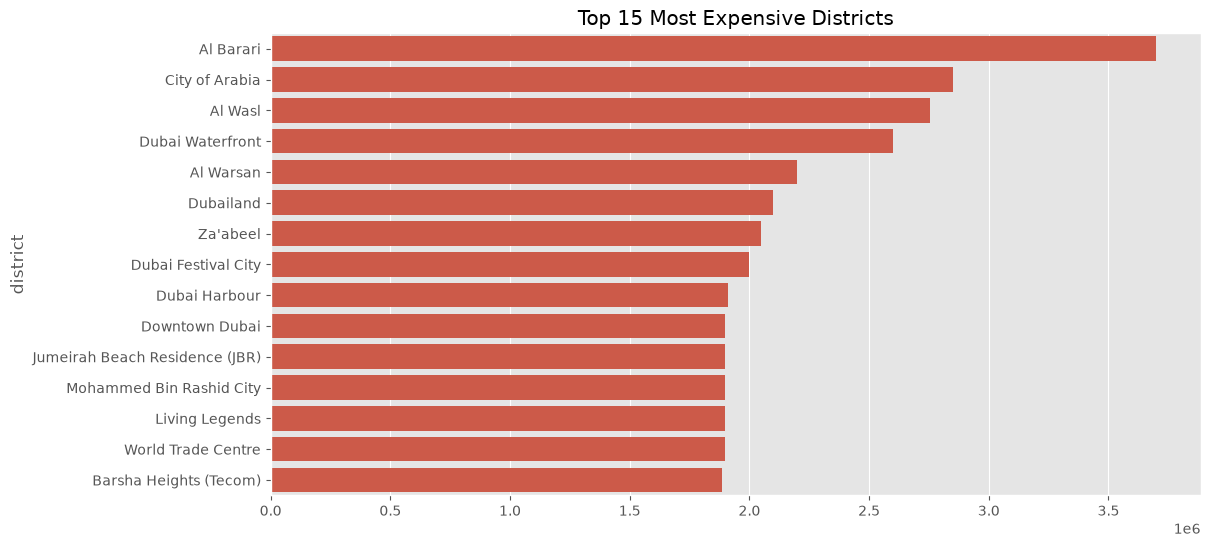

In [19]:
top_districts = (
    df.groupby("district")
      ["price"]
      .median()
      .sort_values(
          ascending=False
      )
      .head(15)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_districts.values,
    y=top_districts.index
)

plt.title(
    "Top 15 Most Expensive Districts"
)

plt.show()

#### 6.7 Correlation Matrix

In [20]:
corr = df[
    [
        "price",
        "area",
        "baths"
    ]
].corr()

corr

,price,area,baths
price,1.000000,0.713907,0.491633
area,0.713907,1.000000,0.755263
baths,0.491633,0.755263,1.000000


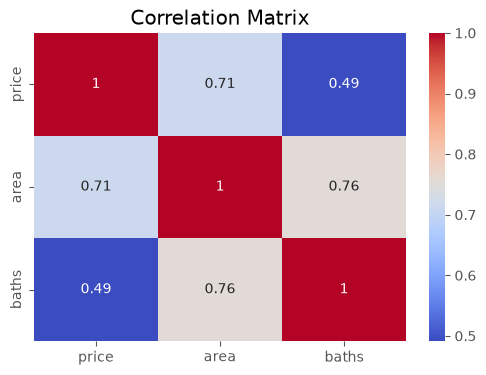

In [21]:
plt.figure(figsize=(6,4))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title(
    "Correlation Matrix"
)

plt.show()

### 7. Feature Engineering

#### 7.1 Price Per SqFt

In [22]:
df["price_per_sqft"] = (
    df["price"]
    /
    df["area"]
)

df["price_per_sqft"].describe()

count    16752.000000
mean      2069.851456
std       1279.198509
min        409.496855
25%       1248.805421
50%       1777.139316
75%       2509.760673
max      21271.806415
Name: price_per_sqft, dtype: float64

#### 7.2 Studio Feature

In [23]:
df["is_studio"] = (
    df["beds"] == 0
).astype(int)

#### 7.3 Luxury Score

In [24]:
df["has_pool"] = (
    (df["private_swimming_pool"] == 1)
    |
    (df["community_swimming_pool"] == 1)
).astype(int)

df["has_sauna"] = (
    (df["private_sauna"] == 1)
    |
    (df["community_sauna"] == 1)
).astype(int)

df["has_parking"] = (
    (df["private_parking"] == 1)
    |
    (df["community_parking"] == 1)
).astype(int)


In [25]:
df[
    [
        "has_pool",
        "has_sauna",
        "has_parking"
    ]
].head()

,has_pool,has_sauna,has_parking
0,1,0,0
1,0,0,0
2,1,1,0
3,0,0,0
4,1,0,0


In [26]:
luxury_cols = [
    "has_pool",
    "has_sauna",
    "has_parking",
    "gym_or_health_club",
    "jacuzzi"
]

df["luxury_score"] = (
    df[luxury_cols]
      .sum(axis=1)
)

In [27]:
df.groupby("luxury_score")["price"] \
  .median() \
  .sort_index()




luxury_score
0.0    1920000.0
1.0    1600000.0
2.0    1370000.0
3.0    1500000.0
4.0    1799000.0
Name: price, dtype: float64

#### 7.4 Log Price

In [28]:
df["log_price"] = np.log1p(
    df["price"]
)

<Axes: >

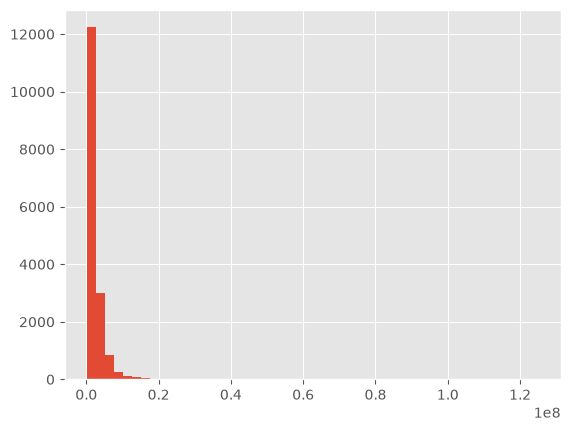

In [29]:
df["price"].hist(
    bins=50
)

<Axes: >

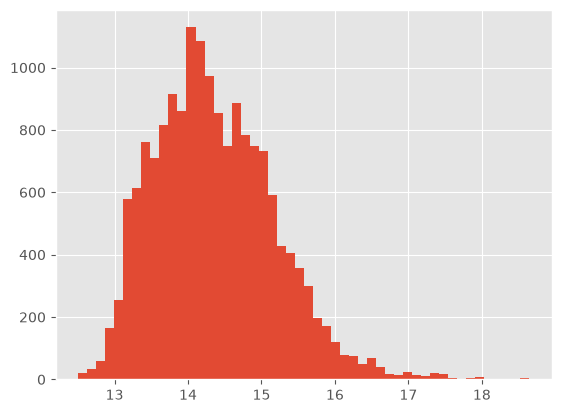

In [30]:
df["log_price"].hist(
    bins=50
)

Observation:

Log transformation significantly reduces skewness and is likely to improve model performance.

#### 8. Key Findings
##### Key Findings

1. Area is the strongest numerical predictor of property price (ρ ≈ 0.71).

2. Property prices are heavily right-skewed.

3. Bedroom and bathroom counts show strong positive relationships with price.

4. Location appears to be a major pricing factor.

5. Price per square foot varies substantially across districts.

6. Luxury amenities may influence valuation but require multivariate analysis.

7. Log-transformed price is a better target for modeling.